## 01 - Data Understanding

To comprehend the final result, first it's important to understand the data, how SoC is calculated and what units need to be used.
 

In [1]:
import openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load dataset

In [2]:
file = "../data/raw/LiFePO4/LiFePO4_5degree.xlsx"

excel = pd.ExcelFile(file)
excel.sheet_names

['1.5C', '1.0C', '0.5C']

In [3]:
df = pd.read_excel(file, sheet_name="1.5C")

df.head()

,Time,Current,Voltage,Capacity(mAh),Energy (mWh),SOC_5D_1.5C_LFP,SOE_5D_1.5C_LFP
0,1,-3600.4,3.3754,0.000000,0.000000,0.000000,0.000000
1,2,-3601.1,3.3475,1.000250,3.360250,0.042693,0.048654
2,3,-3602.6,3.3293,2.000722,6.698472,0.085395,0.096990
3,4,-3601.1,3.3150,3.001194,10.021222,0.128097,0.145101
4,5,-3600.4,3.3035,4.001500,13.331444,0.170793,0.193031


### 2. Inspect columns and dimensions

In [ ]:
print(f"Shape: {df.shape}")

print(f"Columns: {df.columns.tolist()}")

print("Data Types:")
print(df.dtypes)


Shape: (2343, 7)
Columns: ['Time', 'Current', 'Voltage', 'Capacity(mAh)', 'Energy (mWh)', 'SOC_5D_1.5C_LFP', 'SOE_5D_1.5C_LFP']
Data Types:
Time                 int64
Current            float64
Voltage            float64
Capacity(mAh)      float64
Energy (mWh)       float64
SOC_5D_1.5C_LFP    float64
SOE_5D_1.5C_LFP    float64
dtype: object


### 3. Check missing values and duplicates

In [5]:
print(f"Missing values: {df.columns.isnull().sum()}")
print(f"Duplicated values: {df.columns.duplicated().sum().sum()}")

Missing values: 0
Duplicated values: 0


### 4. Inspect beginning and end of experiment

In [6]:
df.head(1)

,Time,Current,Voltage,Capacity(mAh),Energy (mWh),SOC_5D_1.5C_LFP,SOE_5D_1.5C_LFP
0,1,-3600.4,3.3754,0.0,0.0,0.0,0.0


In [7]:
df.tail(1)

,Time,Current,Voltage,Capacity(mAh),Energy (mWh),SOC_5D_1.5C_LFP,SOE_5D_1.5C_LFP
2342,2343,-3601.1,1.9999,2342.898917,6906.364611,100.0,100.0


### 5. Confirm SOC calculation in dataset

In [8]:
df["calculated_percentage"] = (
    df["Capacity(mAh)"] / df["Capacity(mAh)"].max()
) * 100

In [9]:
df[[
    "SOC_5D_1.5C_LFP",
    "calculated_percentage"
]].head(10)

,SOC_5D_1.5C_LFP,calculated_percentage
0,0.000000,0.000000
1,0.042693,0.042693
2,0.085395,0.085395
3,0.128097,0.128097
4,0.170793,0.170793
5,0.213491,0.213491
6,0.256189,0.256189
7,0.298882,0.298882
8,0.341582,0.341582
9,0.384288,0.384288


In [10]:
df[[
    "SOC_5D_1.5C_LFP",
    "calculated_percentage"
]].tail(10)

,SOC_5D_1.5C_LFP,calculated_percentage
2333,99.615712,99.615712
2334,99.658409,99.658409
2335,99.701105,99.701105
2336,99.743803,99.743803
2337,99.786499,99.786499
2338,99.829195,99.829195
2339,99.871894,99.871894
2340,99.914598,99.914598
2341,99.957294,99.957294
2342,100.000000,100.000000


In [11]:
df["difference"] = (
    df["SOC_5D_1.5C_LFP"]
    - df["calculated_percentage"]
)

df["difference"].describe()

count    2.343000e+03
mean    -7.742591e-14
std      4.490952e-14
min     -1.563194e-13
25%     -1.136868e-13
50%     -7.815970e-14
75%     -3.907985e-14
max      0.000000e+00
Name: difference, dtype: float64

### 5. Plot voltage over time

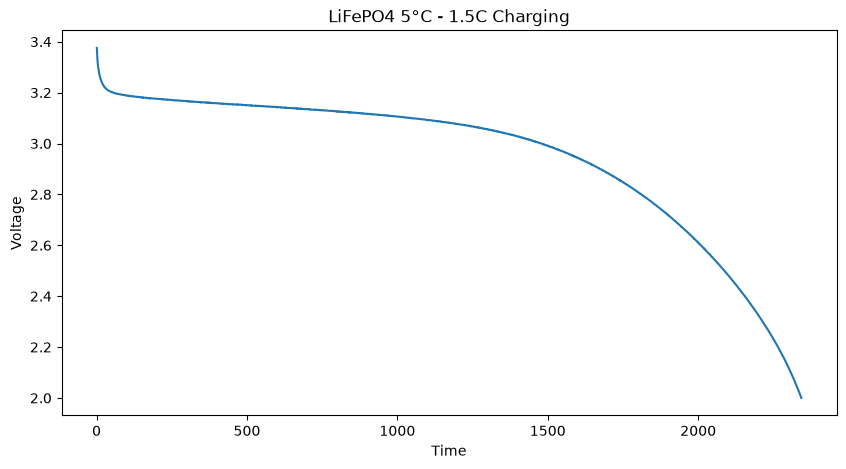

In [12]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df,
    x="Time",
    y="Voltage"
)

plt.title("LiFePO4 5°C - 1.5C Charging")
plt.show()

### 6. Plot SOC over time

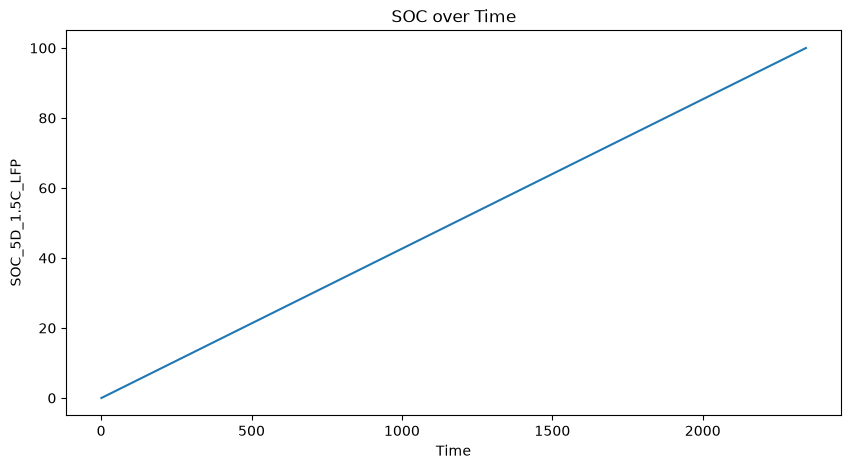

In [13]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df,
    x="Time",
    y="SOC_5D_1.5C_LFP"
)

plt.title("SOC over Time")
plt.show()

### 7. Plot capacity over time

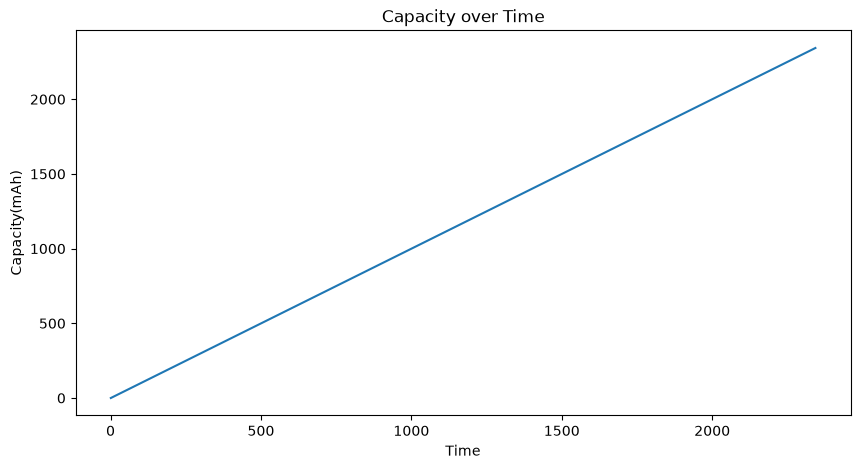

In [14]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df,
    x="Time",
    y="Capacity(mAh)"
)

plt.title("Capacity over Time")
plt.show()

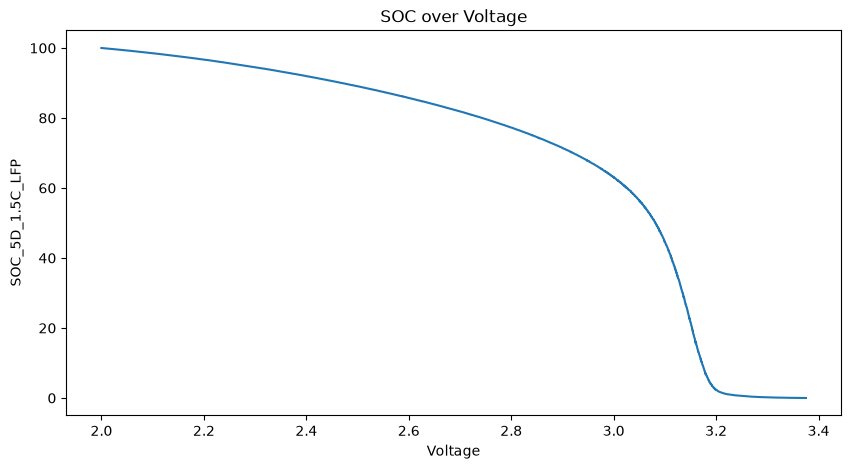

In [15]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df,
    x="Voltage",
    y="SOC_5D_1.5C_LFP"
)

plt.title("SOC over Voltage")
plt.show()

## Initial conclusions


The provided SOC is numerically equivalent to normalized accumulated capacity in the inspected experiment. Because voltage decreases while current is negative, the physical interpretation of the provided SOC variable requires verification.

Accumulated capacity will therefore not be used as an input feature in the first baseline model due to potential target leakage.

The next step is to build a reproducible preprocessing pipeline that standardizes column names, units, and experimental metadata while preserving the raw data unchanged.